In [1]:
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))
from Utility import IdSep
from Utility import Plot
from Utility import Pretraitement
import matplotlib.pyplot as plt

In [2]:
data_path = ROOT / "data" / "EOLENS_6_6.csv"
df = pd.read_csv(data_path)

In [3]:
df

,source_id,lensComponentSourceId,flux_obs,flux_obs_error,isFluxCalibrated,epoch_obs_jd
0,362059596955069568,362059596955069635,707.645797,22.127416,False,2.456895e+06
1,362059596955069568,362059596955069635,447.666962,9.115904,True,2.457021e+06
2,362059596955069568,362059596955069635,421.776240,20.018077,False,2.457073e+06
3,362059596955069568,362059596955069635,752.853455,30.793414,False,2.457254e+06
4,362059596955069568,362059596955069635,336.852112,28.890295,True,2.457351e+06
...,...,...,...,...,...,...
7893240,6897511490746857856,6897511490746857923,551.784302,11.224354,True,2.457381e+06
7893241,6897511490746857856,6897511490746857923,775.916748,12.683733,True,2.458432e+06
7893242,6897511490746857856,6897511490746857923,551.252441,7.974010,True,2.458052e+06
7893243,6897511490746857856,6897511490746857923,491.151428,34.603062,True,2.458827e+06


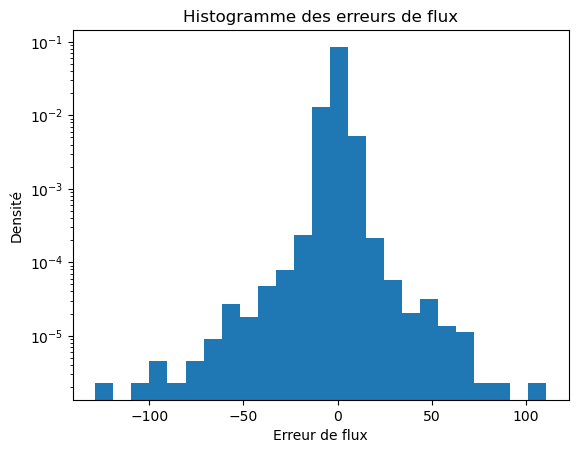

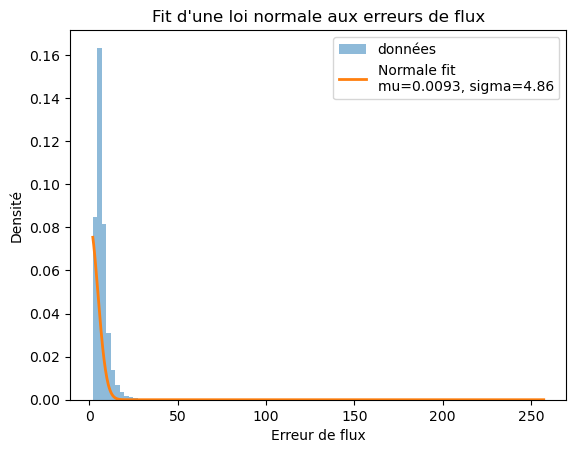

In [ ]:
from scipy import stats
data_path2 = ROOT / "data" / "dgdreq2025nov21_JB.csv"
df2 = pd.read_csv(data_path2)
gt = df2["flux_obs_error"]
g = np.zeros_like(gt)
for i in range(len(gt)):
    g[i] = np.random.choice([-1, 1]) * gt[i] / 2
plt.hist(g, bins=25, log=True, density=True)
plt.title("Histogramme des erreurs de flux")
plt.xlabel("Erreur de flux")
plt.ylabel("Densité")
plt.show()
mu, sigma = stats.norm.fit(g)
x = np.linspace(gt.min(), gt.max(), 1000)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
plt.hist(g, bins=100, density=True, alpha=0.5, label="données")
plt.plot(x, pdf, linewidth=2, label=f"Normale fit\nmu={mu:.3g}, sigma={sigma:.3g}")
plt.title("Fit d'une loi normale aux erreurs de flux")
plt.xlabel("Erreur de flux")
plt.ylabel("Densité")
plt.legend()
plt.show()

In [128]:
def aggregate_bi_daily(df, y_col="flux_obs", x_col="epoch_obs_jd"):
    d = df[[x_col, y_col]].copy()
    d = d.sort_values(x_col)

    d["bin_2d"] = ((d[x_col] - d[x_col].min()) // 4).astype(int)

    out = d.groupby("bin_2d").agg(
        epoch_obs_jd=(x_col, "mean"),
        flux_obs=(y_col, "mean"),
        n_points=(y_col, "size")
    ).reset_index(drop=True)

    return out

In [230]:
def robust_global_mad_bands(
    df,
    y_col="flux_obs",
    x_col="epoch_obs_jd",
    half_window=3,
    sigmas=(2, 3, 4, 5)
):
    d = df[[x_col, y_col]].copy()
    d = d.sort_values(x_col).reset_index(drop=True)

    window = 2 * half_window + 1
    rolling_median = []

    for i in range(len(d)):

        if i < half_window:
            values = d[y_col].iloc[0:window]

        elif i >= len(d) - half_window:
            values = d[y_col].iloc[-window:]

        else:
            values = d[y_col].iloc[i-half_window:i+half_window+1]

        rolling_median.append(np.nanmedian(values))

    d["rolling_median"] = rolling_median

    residuals = d[y_col] - d["rolling_median"]

    global_mad = np.nanmedian(
        np.abs(residuals - np.nanmedian(residuals))
    )

    global_sigma = 1.4826 * global_mad * 4.86

    d["global_mad"] = global_mad
    d["global_sigma_from_mad"] = global_sigma

    for k in sigmas:
        d[f"upper_{k}sigma"] = d["rolling_median"] + k * global_sigma
        d[f"lower_{k}sigma"] = d["rolling_median"] - k * global_sigma

    return d

KeyError: 'flux_obs_error'

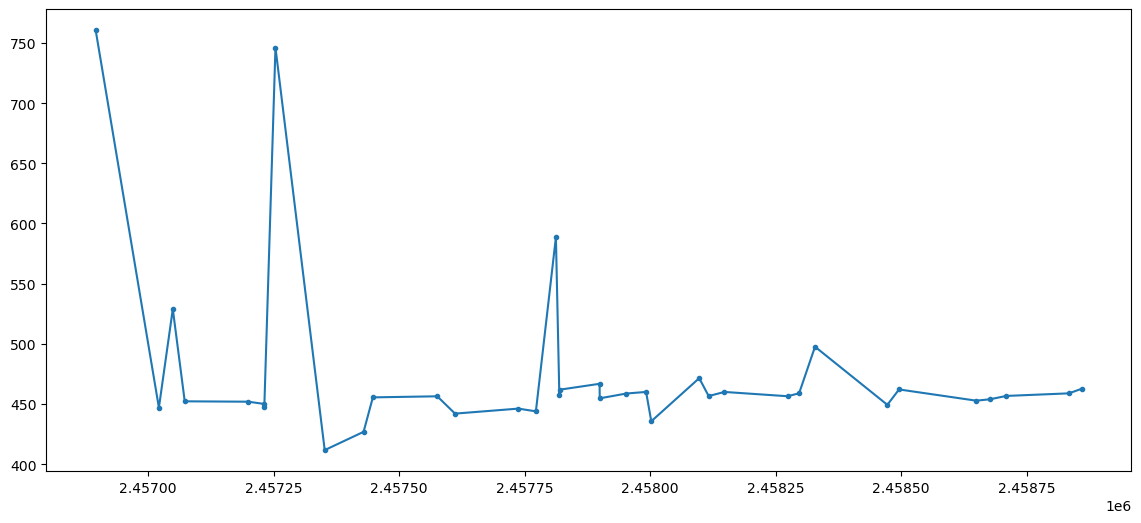

In [ ]:
for i in range(200):
    component_id = df["lensComponentSourceId"].iloc[i*100]

    Test = df[df["lensComponentSourceId"] == component_id].copy()

    Test = aggregate_bi_daily(
    Test,
    y_col="flux_obs",
    x_col="epoch_obs_jd"
    )

    bands = robust_global_mad_bands(
        Test,
        y_col="flux_obs",
        x_col="epoch_obs_jd",
        half_window=3
    )
    plt.figure(figsize=(14, 6))

    plt.plot(bands["epoch_obs_jd"], bands["flux_obs"], ".-", label="flux_obs")
    def aggregate_bi_daily(df, y_col="flux_obs", x_col="epoch_obs_jd", yerr_col=None):
        d = df[[x_col, y_col]].copy()
        d = d.sort_values(x_col)

        d["bin_2d"] = ((d[x_col] - d[x_col].min()) // 4).astype(int)

        out = d.groupby("bin_2d").agg(
            epoch_obs_jd=(x_col, "mean"),
            flux_obs=(y_col, "mean"),
            n_points=(y_col, "size")
        ).reset_index(drop=True)

        if yerr_col is not None:
            e = df[[x_col, yerr_col]].copy()
            e = e.sort_values(x_col)
            e["bin_2d"] = ((e[x_col] - e[x_col].min()) // 4).astype(int)
            e = e.groupby("bin_2d").agg(
                flux_obs_error=(yerr_col, "mean")
            ).reset_index(drop=True)
            out = pd.concat([out, e], axis=1)

        return out
    plt.plot(bands["epoch_obs_jd"], bands["rolling_median"], linewidth=2, label="local median")

    for k in [2, 3, 4, 5]:
        plt.plot(bands["epoch_obs_jd"], bands[f"upper_{k}sigma"], "--", linewidth=1, label=f"+{k}σ")
        plt.plot(bands["epoch_obs_jd"], bands[f"lower_{k}sigma"], "--", linewidth=1, label=f"-{k}σ")

    plt.title("Local median + global MAD bands")
    plt.xlabel("epoch_obs_jd")
    plt.ylabel("flux_obs")
    plt.grid(True)
    plt.legend(ncol=3)
    plt.tight_layout()
    plt.show()

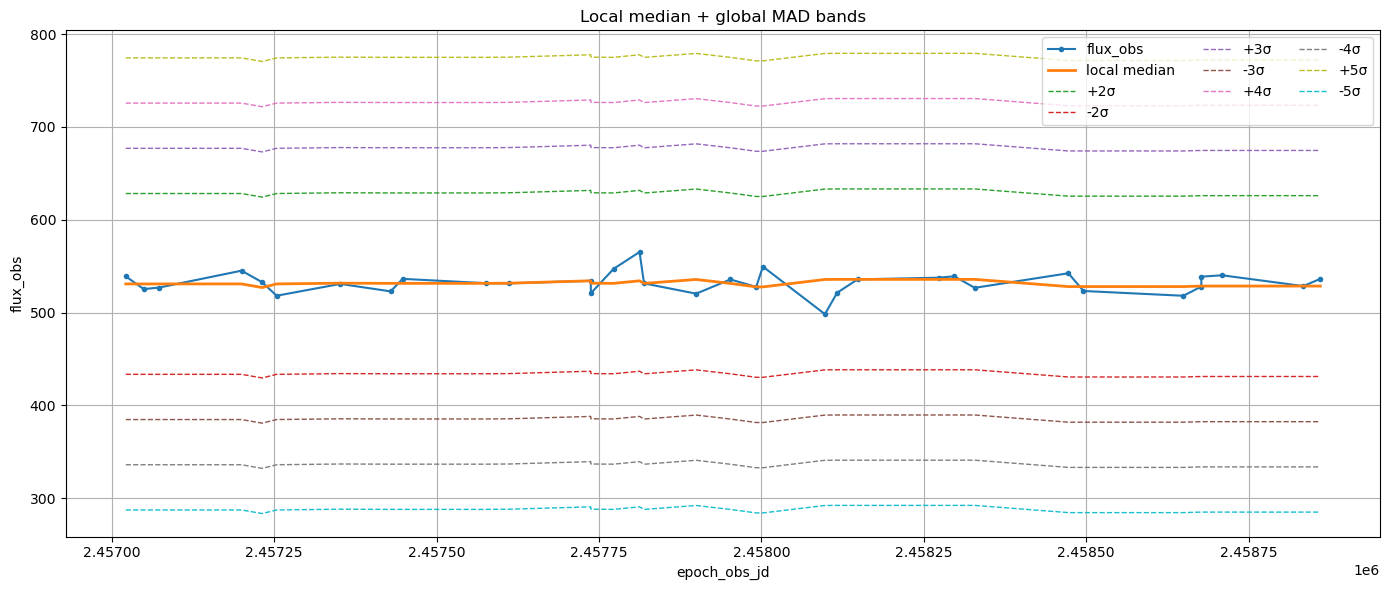

In [98]:
def adaptive_rolling_hybrid_bands(
    df,
    y_col="flux_obs",
    x_col="epoch_obs_jd",
    half_window=3,
    sigmas=(2, 3, 4, 5),
    alpha=0.7,
    c=2.5,
    exclude_center=True
):
    d = df[[y_col, x_col]].copy()
    d = d.sort_values(x_col).reset_index(drop=True)

    window = 2 * half_window + 1

    rolling_median = []
    rolling_sigma = []

    for i in range(len(d)):

        if i < half_window:
            idx = np.arange(0, min(window, len(d)))

        elif i >= len(d) - half_window:
            idx = np.arange(max(0, len(d) - window), len(d))

        else:
            idx = np.arange(i - half_window, i + half_window + 1)

        if exclude_center:
            idx = idx[idx != i]

        values = d[y_col].iloc[idx].values

        med, sigma = robust_hybrid_scale(
            values,
            alpha=alpha,
            c=c
        )

        rolling_median.append(med)
        rolling_sigma.append(sigma)

    d["rolling_median"] = rolling_median
    d["rolling_sigma_hybrid"] = rolling_sigma

    for k in sigmas:
        d[f"upper_{k}sigma"] = d["rolling_median"] + k * d["rolling_sigma_hybrid"]
        d[f"lower_{k}sigma"] = d["rolling_median"] - k * d["rolling_sigma_hybrid"]

    return d

In [99]:
def robust_hybrid_scale(values, alpha=0.7, c=2.5):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    med = np.nanmedian(values)
    r = values - med

    # L1 robust scale: MAD
    mad = np.nanmedian(np.abs(r))
    sigma_mad = 1.4826 * mad

    if sigma_mad == 0 or np.isnan(sigma_mad):
        return med, 0.0

    # Huber / clipped L2 scale
    r_clip = np.clip(r, -c * sigma_mad, c * sigma_mad)
    sigma_l2_clip = np.sqrt(np.nanmean(r_clip**2))

    # Hybrid L1 + clipped L2
    sigma = alpha * sigma_mad + (1 - alpha) * sigma_l2_clip

    return med, sigma

In [184]:
component_id = df["lensComponentSourceId"].iloc[3900] #2000

Test = df[df["lensComponentSourceId"] == component_id].copy()

Test = aggregate_bi_daily(
    Test,
    y_col="flux_obs",
    x_col="epoch_obs_jd"
)

bands = adaptive_rolling_hybrid_bands(
    Test,
    y_col="flux_obs",
    x_col="epoch_obs_jd",
    half_window=5,
    alpha=0.7,
    c=2.5,
    exclude_center=True
)

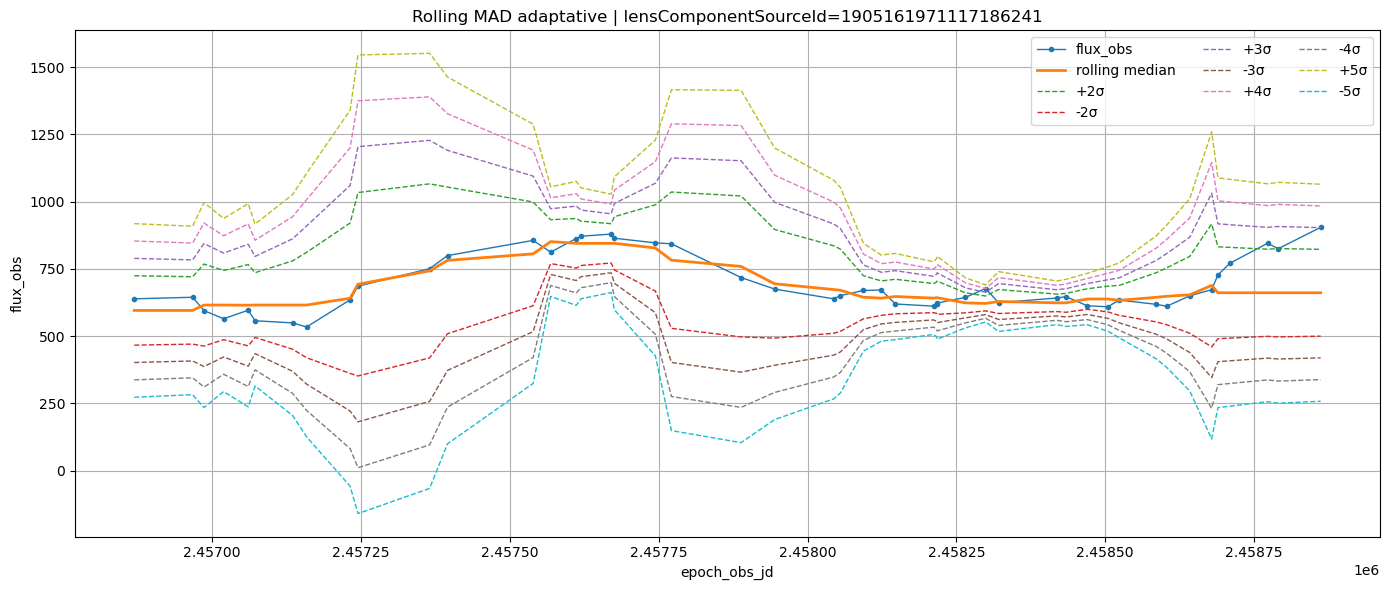

In [185]:
plt.figure(figsize=(14, 6))

plt.plot(bands["epoch_obs_jd"], bands["flux_obs"], marker=".", linewidth=1, label="flux_obs")
plt.plot(bands["epoch_obs_jd"], bands["rolling_median"], linewidth=2, label="rolling median")

for k in [2, 3, 4, 5]:
    plt.plot(bands["epoch_obs_jd"], bands[f"upper_{k}sigma"], "--", linewidth=1, label=f"+{k}σ")
    plt.plot(bands["epoch_obs_jd"], bands[f"lower_{k}sigma"], "--", linewidth=1, label=f"-{k}σ")

plt.title(f"Rolling MAD adaptative | lensComponentSourceId={component_id}")
plt.xlabel("epoch_obs_jd")
plt.ylabel("flux_obs")
plt.grid(True)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()